# 2. Loading the Covertype Dataset

In [1]:
from sklearn.datasets import fetch_covtype
import pandas as pd

# Load the dataset
covtype = fetch_covtype(as_frame=True)  # Returns a DataFrame
X = covtype.data  # Features
y = covtype.target - 1  # Target (adjusted to 0-6 for zero-based indexing)

In [2]:
X

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
X.shape

(581012, 54)

In [4]:
y

0         4
1         4
2         1
3         1
4         4
         ..
581007    2
581008    2
581009    2
581010    2
581011    2
Name: Cover_Type, Length: 581012, dtype: int32

In [5]:
sample_size = 20000
# Ensure we get a balanced sample across all classes
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=sample_size, random_state=42, stratify=y
)
X = X_sample
y = y_sample

# 3. Visualizing the Dataset

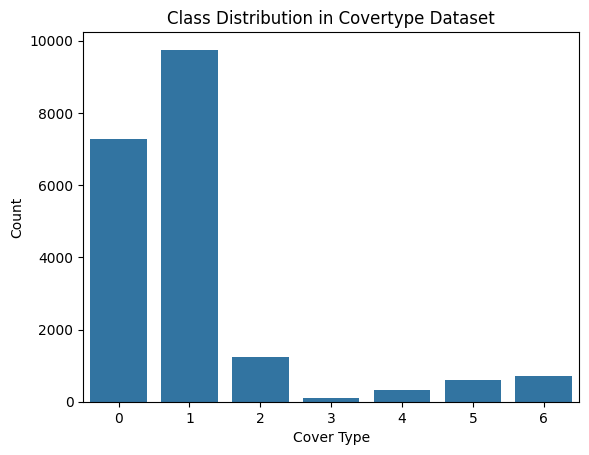

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title('Class Distribution in Covertype Dataset')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

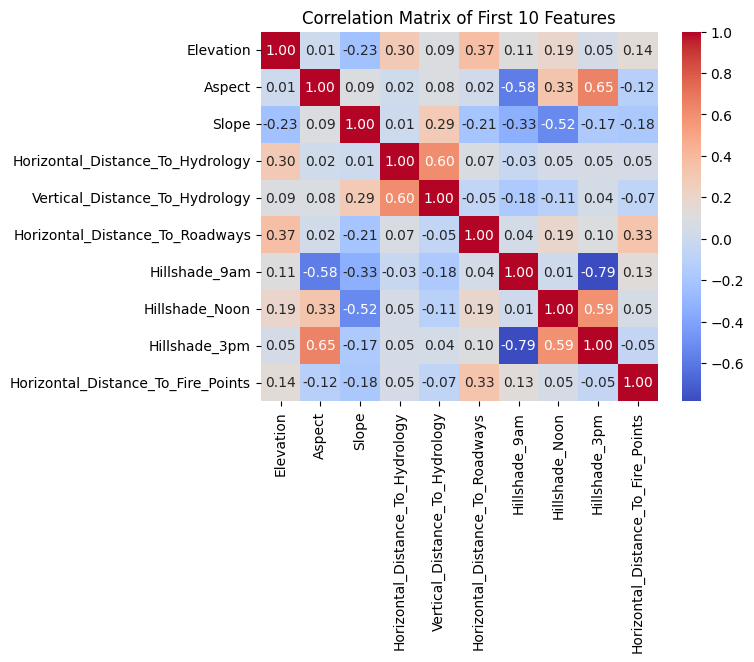

In [7]:
# Select first 10 features for simplicity
subset = X.iloc[:, :10]

# Compute correlation matrix
corr = subset.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of First 10 Features')
plt.show()

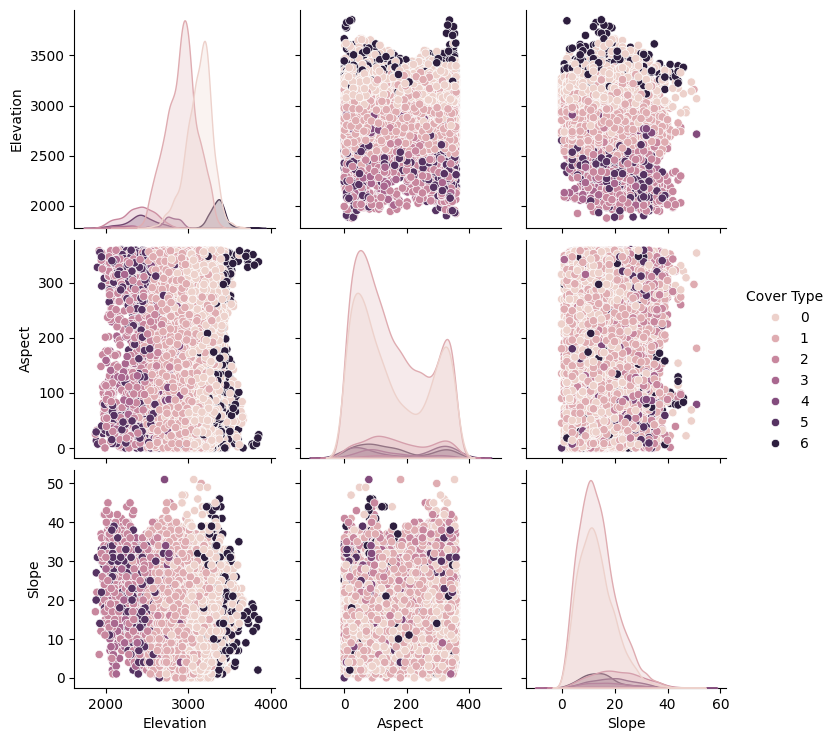

In [8]:
# Combine features and target for a sample
sample = X.iloc[:, :3].copy()  # First 3 features
sample['Cover Type'] = y

sns.pairplot(sample, hue='Cover Type', diag_kind='kde')
plt.show()

# 4. Train and evaluate CatBoost with default settings

In [9]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the dataset into training, validation and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Initialize the CatBoost model with default settings
model = CatBoostClassifier(verbose=0, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Accuracy: 83.43%


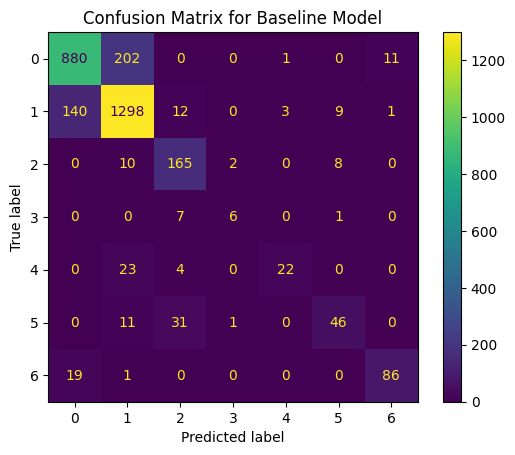

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix for Baseline Model')
plt.show()

# 5. Implementing Hyperparameter Tuning with Optuna

In [11]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        # TODO: Investigate CatBoost docs and add more hyperparameters
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 6, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 0, 1),
        'loss_function': 'MultiClass',
        'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.1, 1., log=True)   ,
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.01, 1.)  
    }
    # TODO: 
    # 1. Train CatBoost using params
    # 2. Return validation accuracy score as result
    # Area for improvement: use Cross-Validation instead of a single train/val split.
    model = CatBoostClassifier(**params, verbose=0, random_state=42)
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid), early_stopping_rounds=50)
    # ,verbose=0
    y_pred = model.predict(X_valid)
    accuracy = accuracy_score(y_valid, y_pred)

    return accuracy
    

In [12]:
# Create the study
study_name = 'catboost_optimization'
storage_name = 'sqlite:///example.db'
study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction='maximize',
    load_if_exists=True
)
# maximize bc we use the accuracy metric not loss function like in gradient decent
study.optimize(objective, n_trials=10, n_jobs=-1)  # Run 20 trials

[I 2026-04-17 13:13:29,203] Using an existing study with name 'catboost_optimization' instead of creating a new one.
[I 2026-04-17 13:14:45,414] Trial 71 finished with value: 0.8533333333333334 and parameters: {'iterations': 638, 'learning_rate': 0.14754790316201727, 'depth': 8, 'l2_leaf_reg': 1.3524539480000364, 'random_strength': 0.7910845322826454, 'boosting_type': 'Ordered', 'colsample_bylevel': 0.7810628516915598, 'bagging_temperature': 0.08693885557526859}. Best is trial 71 with value: 0.8533333333333334.
[I 2026-04-17 13:14:50,475] Trial 74 finished with value: 0.8546666666666667 and parameters: {'iterations': 739, 'learning_rate': 0.1513751476259455, 'depth': 8, 'l2_leaf_reg': 1.0193843402857812, 'random_strength': 0.7679895046200003, 'boosting_type': 'Ordered', 'colsample_bylevel': 0.7932057437811693, 'bagging_temperature': 0.08471310871021204}. Best is trial 74 with value: 0.8546666666666667.
[I 2026-04-17 13:14:53,322] Trial 70 finished with value: 0.858 and parameters: {'it

# 6. Setting up Optuna Dashboard

Launching optimization monitor
```bash
optuna-dashboard sqlite:///example.db
```

Best result provided by Optuna:

<img src="./best_result.png" width="100%">

And the hyper parameters importance chart:

<img src="./hyper_parameters_importance.png" width="50%">

# 7. Post-Optimization Steps: Analyzing Results and Final Evaluation

In [13]:
# Retrieve the best trial from the study
best_trial = study.best_trial

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_trial.value:.4f}")
print("Best Hyperparameters Found:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best Trial Number: 73
Best Validation Accuracy: 0.8637
Best Hyperparameters Found:
  iterations: 717
  learning_rate: 0.1492498625445922
  depth: 8
  l2_leaf_reg: 1.3458284870394541
  random_strength: 0.7697873981693196
  boosting_type: Ordered
  colsample_bylevel: 0.8675148306519513
  bagging_temperature: 0.08523644810151414


In [14]:
best_params = best_trial.params

# --- IMPORTANT: Combine Training and Validation Data ---
# Create the full training dataset (train + validation) for the final model
X_train_full = pd.concat([X_train, X_valid], ignore_index=True)
y_train_full = pd.concat([y_train, y_valid], ignore_index=True)

final_params = best_params.copy()
final_params['random_state'] = 42

final_model = CatBoostClassifier(**final_params, verbose=0)
final_model.fit(X_train_full, y_train_full)

CatBoostClassifier(bagging_temperature=0.08523644810151414, boosting_type='Ordered', colsample_bylevel=0.8675148306519513, depth=8, iterations=717, l2_leaf_reg=1.3458284870394541, learning_rate=0.1492498625445922, random_state=42, random_strength=0.7697873981693196, verbose=0)

--- Performance Comparison ---
Baseline Accuracy (on Test Set): 83.43%
Optimized Accuracy (on Test Set): 86.37%
Improvement due to HPO: 2.93%
Confusion Matrix for Final Optimized Model (on Test Set):


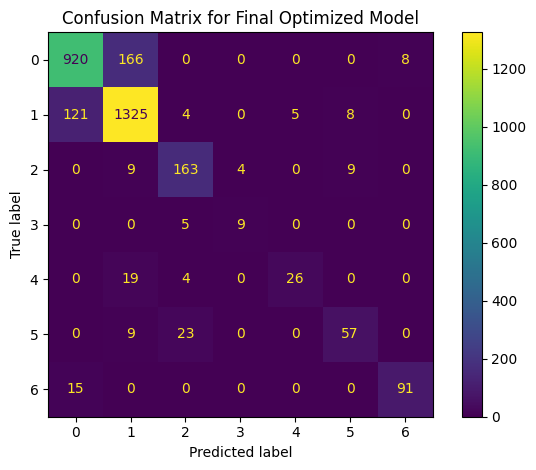

In [15]:
y_pred_test = final_model.predict(X_test)

# Calculate final accuracy
final_accuracy = accuracy_score(y_test, y_pred_test)

print("--- Performance Comparison ---")
# Assuming baseline_accuracy variable holds the score from Step 5
print(f"Baseline Accuracy (on Test Set): {baseline_accuracy * 100:.2f}%")
print(f"Optimized Accuracy (on Test Set): {final_accuracy * 100:.2f}%")
improvement = final_accuracy - baseline_accuracy
print(f"Improvement due to HPO: {improvement * 100:.2f}%")

print("Confusion Matrix for Final Optimized Model (on Test Set):")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title('Confusion Matrix for Final Optimized Model')
plt.tight_layout()
plt.show()

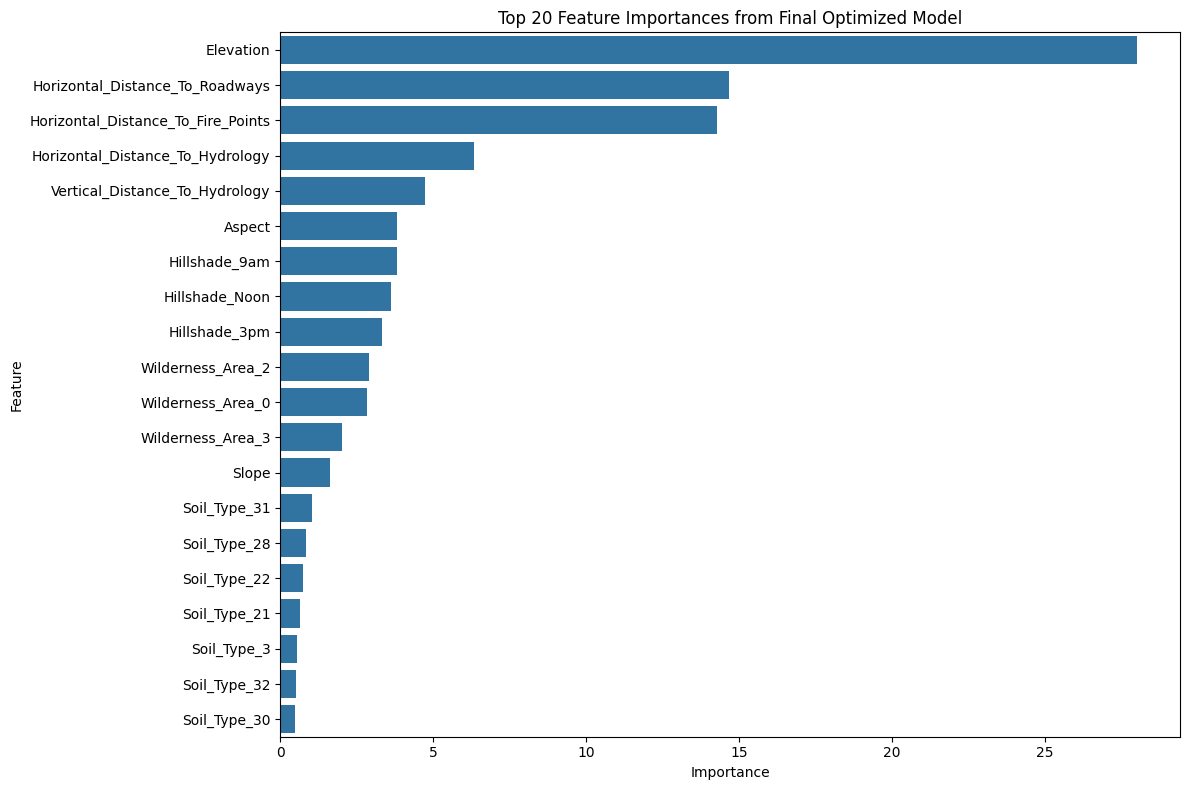

In [16]:
importances = final_model.get_feature_importance()
feature_names = X_train_full.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Final Optimized Model')
plt.tight_layout()
plt.show()